# SETUP

In [2]:
# Janky code to do different setup when run in a Colab notebook vs VSCode
import os

from IPython import get_ipython

# ipython = get_ipython()
# # Code to automatically update the HookedTransformer code as its edited without restarting the kernel
# ipython.magic("load_ext autoreload")
# ipython.magic("autoreload 2")
# Import stuff
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
from fancy_einsum import einsum
import tqdm.notebook as tqdm
import random
from pathlib import Path
import plotly.express as px
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from torchtyping import TensorType as TT
from typing import List, Union, Optional, Callable
from functools import partial
import copy
import itertools
import json

from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer
import dataclasses
import datasets
from IPython.display import HTML, Markdown
import umap

In [3]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)  # Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

In [4]:
# from neel_plotly import line, imshow, scatter
# import plotly.io as pio
# pio.renderers.default = 'vscode'

#import transformer_lens.patching as patching

from typing_extensions import Literal

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

# import kmapper as km
import sklearn.manifold as manifold
from sklearn.cluster import DBSCAN

import sys
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MaxAbsScaler
import networkx as nx
import pandas as pd


## IOI SETUP

In [5]:
model = HookedTransformer.from_pretrained("gpt2-small")


model.set_use_attn_result(True)
model.set_use_attn_in(True)
model.set_use_hook_mlp_in(True)

Loaded pretrained model gpt2-small into HookedTransformer


In [6]:

import random

def generate_random_ioi_samples(num_samples=10):
    """Generate random IOI-style samples (prompts + (IO, S) answers)."""

    # Some example names, places, objects, and verbs
    names = [
        "John", "Mary", "Tom", "Amy", "James", "Alice", "Mark", "Lisa",
        "Dan", "Max", "Sam", "Eva", "Jane", "Luke", 
        "Bob", "Kate", "Ben"
    ]
    places = [
        "the store", "the park", "the shops", "the beach",
        "the museum", "the school", "the cafe", "the mall"
    ]
    objects = [
        "bag", "ball", "apple", "book", "drink", "gift",
        "sandwich", "toy", "phone", "note"
    ]
    verbs = [
        "gave", "handed", "passed", "offered", "brought",
        "delivered", "presented"
    ]

    prompts = []
    answers = []

    for _ in range(num_samples):
        # Pick 2 distinct names
        name1, name2 = random.sample(names, 2)
        # Pick a place, object, and verb
        place = random.choice(places)
        obj = random.choice(objects)
        verb = random.choice(verbs)

        # Randomly choose who is subject (giver) and who is indirect object (receiver)
        if random.random() < 0.5:
            subject = name1
            indirect_object = name2
        else:
            subject = name2
            indirect_object = name1

        # Construct the prompt
        prompt = f"When {name1} and {name2} went to {place}, {subject} {verb} the {obj} to"

        # The answer is (IO, S) in a tuple
        answers_tuple = (indirect_object, subject)

        prompts.append(prompt)
        answers.append(answers_tuple)

    return prompts, answers

In [7]:
num_samples=5000
prompts, answers = generate_random_ioi_samples(num_samples)

clean_tokens = model.to_tokens(prompts)
# Swap each adjacent pair, with a hacky list comprehension
corrupted_tokens = clean_tokens[
    [(i + 1 if i % 2 == 0 else i - 1) for i in range(len(clean_tokens))]
]
print("Clean string 0", model.to_string(clean_tokens[0]))
print("Corrupted string 0", model.to_string(corrupted_tokens[0]))

answer_token_indices = torch.tensor(
    [
        [model.to_single_token(answers[i][j]) for j in range(2)]
        for i in range(len(answers))
    ],
    device=model.cfg.device,
)
print("Answer token indices", answer_token_indices)

Clean string 0 <|endoftext|>When Max and John went to the cafe, Max presented the note to
Corrupted string 0 <|endoftext|>When Alice and Sam went to the park, Sam presented the phone to
Answer token indices tensor([[ 7554, 11518],
        [44484, 16305],
        [44203, 40797],
        ...,
        [45087, 40797],
        [11518,  9704],
        [44203, 45087]])


In [8]:
def get_logit_diff(logits, answer_token_indices=answer_token_indices):
    if len(logits.shape) == 3:
        # Get final logits only
        logits = logits[:, -1, :]
    correct_logits = logits.gather(1, answer_token_indices[:, 0].unsqueeze(1))
    incorrect_logits = logits.gather(1, answer_token_indices[:, 1].unsqueeze(1))
    return (correct_logits - incorrect_logits).mean()

In [9]:
def filter_mlp_hooks(name):
    return "mlp" in name

def get_cache_fwd_and_bwd(model, tokens, metric):
    model.reset_hooks()
    cache = {}

    def forward_cache_hook(act, hook):
        cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, forward_cache_hook, "fwd")

    grad_cache = {}

    def backward_cache_hook(act, hook):
        grad_cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, backward_cache_hook, "bwd")

    value = metric(model(tokens))
    value.backward()
    model.reset_hooks()
    return (
        value.item(),
        ActivationCache(cache, model),
        ActivationCache(grad_cache, model),
    )

def get_cache_fwd(model, tokens, metric):
    model.reset_hooks()
    cache = {}

    def forward_cache_hook(act, hook):
        cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, forward_cache_hook, "fwd")

    grad_cache = {}

    value = metric(model(tokens))
    model.reset_hooks()
    return (
        value.item(),
        ActivationCache(cache, model),
        ActivationCache(grad_cache, model),
    )

In [10]:
def stack_mlp_from_cache(cache, activation_name: Literal["mlp_in", "mlp_out", "pre", "post"]):
    stacked_mlp_vectors = torch.stack(
        [cache[activation_name, l] for l in range(model.cfg.n_layers)], dim=0
    )

    return stacked_mlp_vectors

# Clustering Neurons 

## Computing Attribution Vectors

 - For each neuron we will compute an attribuition score per sample vector.
 - Denote $attr_{x_i}$ the attribution score for neuron $x$ on input $i$.
 - For each neuron $x$ we will compute vector $v_x \in \R^{batch}$ where $v_{x_i} = atr_{x_i}$

In [11]:
num_layers = model.cfg.n_layers

def get_sample_attribution_vectors(clean_cache, corrupted_cache, corrupted_grad_cache, sum_over_pos=False):
    clean_act = stack_mlp_from_cache(clean_cache, "post")
    corrupted_act = stack_mlp_from_cache(corrupted_cache, "post")
    grad_vector = stack_mlp_from_cache(corrupted_grad_cache, "post")
    

    if sum_over_pos:
        attribution_scores = einops.reduce(
            grad_vector * (clean_act - corrupted_act),
            "layer batch pos dim -> layer dim batch",
            'sum'
        )
    else:
        attribution_scores = einops.rearrange(
            grad_vector * (clean_act - corrupted_act),
            "layer batch pos dim -> layer (pos dim) batch"
        )
    
    return attribution_scores


def get_sample_activation_vectors(clean_cache, sum_over_pos=False):
    clean_act = stack_mlp_from_cache(clean_cache, "post")

    if sum_over_pos:
        attribution_scores = einops.reduce(
            clean_act,
            "layer batch pos dim -> layer dim batch",
            'sum'
        )
    else:
        attribution_scores = einops.rearrange(
            clean_act,
            "layer batch pos dim -> layer (pos dim) batch"
        )
    
    return attribution_scores

In [50]:
num_layers = model.cfg.n_layers

def stack_w_out():
    W_out_stacked = torch.stack(
        [model.blocks[l].mlp.W_out for l in range(num_layers)], dim=0
    )

    return W_out_stacked


def get_mlp_output_attribution_matrices(clean_cache, corrupted_cache, corrupted_grad_cache, sum_over_pos=False, weighted_by_attribution_score=False):
    clean_act_post = stack_mlp_from_cache(clean_cache, "post")

    clean_act_post = einops.reduce(
        clean_act_post,
        "layer batch pos dim -> layer pos dim",
        "sum"
    )

    W_out_stacked = stack_w_out()

    W_out_stacked = einops.rearrange(
        W_out_stacked,
        "layer d_mlp d_embed -> layer d_embed d_mlp"
    )

    attribution_matrices = einops.einsum(
        clean_act_post,
        W_out_stacked,
        "layer pos d_mlp, layer d_embed d_mlp -> layer pos d_embed d_mlp"
    )


    attribution_matrices = einops.rearrange(
        attribution_matrices,
        "layer pos d_embed d_mlp -> layer pos d_mlp d_embed"
    )

    if(weighted_by_attribution_score):
        clean_act = stack_mlp_from_cache(clean_cache, "post")
        corrupted_act = stack_mlp_from_cache(corrupted_cache, "post")
        grad_vector = stack_mlp_from_cache(corrupted_grad_cache, "post")
        
        attribution_scores = einops.reduce(
            grad_vector * (clean_act - corrupted_act),
            "layer batch pos dim -> layer pos dim",
            "sum"
        )

        attribution_matrices = einops.einsum(
            attribution_scores,
            attribution_matrices,
            "layer pos d_mlp, layer pos d_mlp d_embed -> layer pos d_mlp d_embed"
        )

    if(sum_over_pos):
        return einops.reduce(
            attribution_matrices,
            "layer pos d_mlp d_embed -> layer d_mlp d_embed",
            "sum"
        )
    
    else:
        return einops.rearrange(
            attribution_matrices,
            "layer pos d_mlp d_embed -> layer (pos d_mlp) d_embed"
        )


def throw_low_activation_neuron(clean_cache, attributions, threshold=0.1):
    clean_act = stack_mlp_from_cache(clean_cache, "post")
    
    clean_act = einops.reduce(
        torch.abs(clean_act),
        "layer batch pos d_mlp -> layer pos d_mlp",
        "sum"
    )
    
    clean_act = einops.rearrange(
        clean_act,
        "layer pos d_mlp -> layer (pos d_mlp)",
    )
    mask = clean_act > threshold

    while(mask.dim() < attributions.dim()):
        mask = mask.unsqueeze(-1)
    
    
    mask = mask.expand_as(attributions)
    filtered_out = attributions * mask
    
    return filtered_out


def throw_low_attribution_neuron(attributions, clean_cache, corrupted_cache, grad_cache, sum_over_pos=False):
    clean_act = stack_mlp_from_cache(clean_cache, "post")
    corrupted_act = stack_mlp_from_cache(corrupted_cache, "post")
    grad_vector = stack_mlp_from_cache(grad_cache, "post")
    
    attribution_scores = einops.reduce(
        grad_vector * (clean_act - corrupted_act),
        "layer batch pos d_mlp -> layer pos d_mlp",
        "sum"
    )

    # attribution_scores = attribution_scores.abs()
    if (sum_over_pos):
        attribution_scores = einops.reduce(
            attribution_scores,
            "layer pos d_mlp -> layer d_mlp",
            "sum"
        )
    else:
        attribution_scores = einops.rearrange(
            attribution_scores,
            "layer pos d_mlp -> layer (pos d_mlp)",
        )

    topk_values, _ = torch.topk(attribution_scores.flatten(), k=5000)
    threshold = topk_values[-1].item()
    mask = attribution_scores >= threshold
    
    while(mask.dim() < attributions.dim()):
        mask = mask.unsqueeze(-1)
    filtered_out = attributions * mask.expand_as(attributions)
    # mask = attribution_scores.view(12, 15, 3072).sum(-1) >= threshold
    
    return filtered_out, mask




def get_neuron_colors(attr, d_mlp=3072):
    colors = torch.zeros((attr.shape[1]))

    for i in range(attr.shape[1]):
        colors[i] = i//d_mlp

    return colors


# Activation vectors clustering (entry is act on sample)

In [13]:
p = prompts[:8]
a = answers[:8]

clean_tokens = model.to_tokens(p)
# Swap each adjacent pair, with a hacky list comprehension
corrupted_tokens = clean_tokens[
    [(i + 1 if i % 2 == 0 else i - 1) for i in range(len(clean_tokens))]
]

answer_token_indices = torch.tensor(
    [
        [model.to_single_token(a[i][j]) for j in range(2)]
        for i in range(len(a))
    ],
    device=model.cfg.device,
)

clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

clean_logit_diff = get_logit_diff(clean_logits, answer_token_indices).item()

corrupted_logit_diff = get_logit_diff(corrupted_logits, answer_token_indices).item()


CLEAN_BASELINE = clean_logit_diff
CORRUPTED_BASELINE = corrupted_logit_diff

def ioi_metric(logits, answer_token_indices=answer_token_indices):
    return (get_logit_diff(logits, answer_token_indices) - CORRUPTED_BASELINE) / (
        CLEAN_BASELINE - CORRUPTED_BASELINE
    )


clean_value, clean_cache, clean_grad_cache = get_cache_fwd_and_bwd(
    model, clean_tokens, ioi_metric
)

corrupted_value, corrupted_cache, corrupted_grad_cache = get_cache_fwd_and_bwd(
    model, corrupted_tokens, ioi_metric
)

clean_act = stack_mlp_from_cache(clean_cache, "post")
corrupted_act = stack_mlp_from_cache(corrupted_cache, "post")
grad_vector = stack_mlp_from_cache(corrupted_grad_cache, "post")

attribution_scores = einops.reduce(
    grad_vector * (clean_act - corrupted_act),
    "layer batch pos d_mlp -> layer pos d_mlp",
    "sum"
)

attribution_scores = einops.reduce(
    grad_vector * (clean_act - corrupted_act),
    "layer batch pos d_mlp -> layer d_mlp",
    "sum"
)

In [ ]:
num_batches = np.ceil(num_samples/32)

for i in range(num_batches):
    p = prompts[32*i : 32*(i+1)]
    a = answers[32*i : 32*(i+1)]
    
    clean_tokens = model.to_tokens(p)
    
    corrupted_tokens = clean_tokens[
        [(i + 1 if i % 2 == 0 else i - 1) for i in range(len(clean_tokens))]
    ]

    answer_token_indices = torch.tensor(
        [
            [model.to_single_token(a[i][j]) for j in range(2)]
            for i in range(len(a))
        ],
        device=model.cfg.device,
    )

In [51]:
X = get_sample_activation_vectors(clean_cache)
X, mask = throw_low_attribution_neuron(X, clean_cache, corrupted_cache, corrupted_grad_cache)

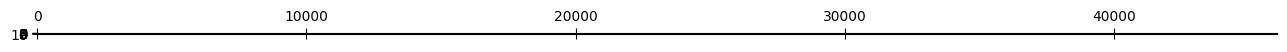

In [52]:
plt.matshow(mask)

In [16]:
model.tokenizer.tokenize(prompts[0])

['When',
 'ĠMax',
 'Ġand',
 'ĠJohn',
 'Ġwent',
 'Ġto',
 'Ġthe',
 'Ġcafe',
 ',',
 'ĠMax',
 'Ġpresented',
 'Ġthe',
 'Ġnote',
 'Ġto']

Ellipsis

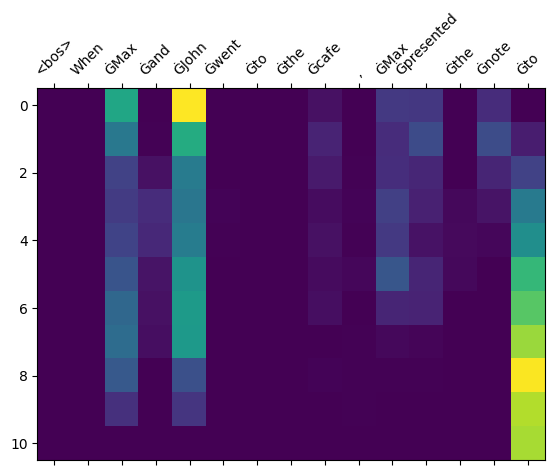

In [53]:
plt.matshow(mask.view(mask.size(0), -1, 3072).sum(-1)[1:])
plt.xticks(np.arange(15), ['<bos>'] + model.tokenizer.tokenize(prompts[0]), rotation=45)
...

In [45]:
mask.sum(dim=[-1, -2])

tensor([122,  40,  26,  17,  24,  26,  44,  47,  51,  51,  28,  24])

## Clustering

In [ ]:

clusterer = DBSCAN(eps=0.3, min_samples=16)

all_layers_clusters = []
for l in range(num_layers):
    non_empty_mask = X[l].abs().sum(dim=1).bool()
    filtered_data = X[l, non_empty_mask, :].cpu().detach().numpy()

    c = clusterer.fit(filtered_data)
    all_layers_clusters.append(c)

In [ ]:
for l in range(num_layers): 
    print(set(all_layers_clusters[l].labels_))
    print(pd.Series(all_layers_clusters[l].labels_).value_counts(normalize=True).reset_index())

## Visualization

## Evaluation (still unclear)